In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image


In [8]:
train_dir     ='/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Training'
validation_dir='/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Validation'

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from tensorflow.keras.preprocessing import image_dataset_from_directory

In [11]:
ds_train = image_dataset_from_directory(
    train_dir,
    image_size=(256, 256),  
    batch_size=32,
    label_mode='categorical', 
    shuffle=True
)

Found 3087 files belonging to 7 classes.


In [12]:
ds_val = image_dataset_from_directory(
    validation_dir,
    image_size=(256, 256),
    batch_size=32,
    label_mode='categorical',
    shuffle=False
)


Found 1028 files belonging to 7 classes.


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_val   = ds_val.cache().prefetch(buffer_size=AUTOTUNE)

In [15]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

print("Total layers in ResNet50:", len(base_model.layers))


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total layers in ResNet50: 175


In [16]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

IMG_SIZE = 256
NUM_CLASSES = 7

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = True


In [17]:
freeze_layers = 140

In [18]:
for layer in base_model.layers[:freeze_layers]:
    layer.trainable = False

for layer in base_model.layers[freeze_layers:]:
    layer.trainable = True


In [19]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = preprocess_input(inputs)

x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    256,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [21]:
history = model.fit(
ds_train,
validation_data=ds_val,
epochs=15
)

Epoch 1/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 762s 8s/step - accuracy: 0.2194 - loss: 2.5630 - val_accuracy: 0.5146 - val_loss: 1.8406
Epoch 2/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 727s 8s/step - accuracy: 0.4865 - loss: 1.8349 - val_accuracy: 0.7072 - val_loss: 1.4337
Epoch 3/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 746s 8s/step - accuracy: 0.6771 - loss: 1.4224 - val_accuracy: 0.8084 - val_loss: 1.1765
Epoch 4/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 733s 8s/step - accuracy: 0.8042 - loss: 1.1431 - val_accuracy: 0.8706 - val_loss: 1.0105
Epoch 5/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 745s 8s/step - accuracy: 0.8723 - loss: 0.9590 - val_accuracy: 0.9037 - val_loss: 0.8893
Epoch 6/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 798s 8s/step - accuracy: 0.9278 - loss: 0.8106 - val_accuracy: 0.9270 - val_loss: 0.7971
Epoch 7/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 724s 7s/step - accuracy: 0.9489 - loss: 0.7205 - val_accuracy: 0.9387 - val_loss: 0.7269
Epoch 8/15
97/97 ━━━━━━━━━━━━━━━━━━━━ 721s 7s/step - accuracy: 0.9693 - loss: 0.6413 - val_accuracy: 0.9504 - v

In [22]:
# Save the model in Native Keras format
model.save("teeth_classifier_resnet50.keras")



In [23]:
from tensorflow.keras.models import load_model

model = load_model("teeth_classifier_resnet50.keras")


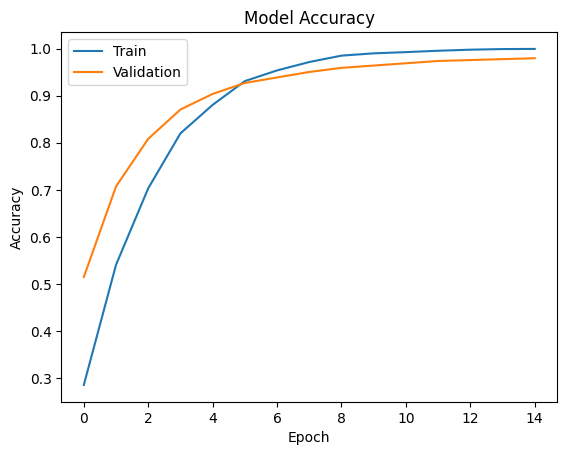

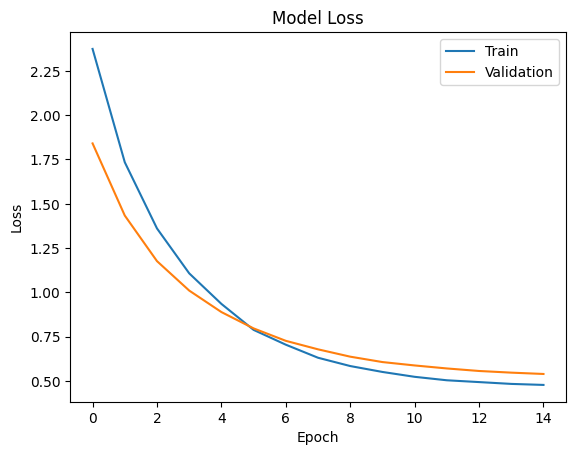

In [24]:
# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [25]:

import os

train_dir = '/kaggle/input/teeth-dataset-cellula/Teeth_Dataset/Training'

# Extract folder names (each folder represents a class)
class_names = sorted([folder for folder in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, folder))])

print("Class Names:", class_names)




Class Names: ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']


33/33 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step
              precision    recall  f1-score   support

         CaS       0.99      0.98      0.98       160
         CoS       0.99      1.00      1.00       149
         Gum       1.00      0.95      0.97       120
          MC       0.97      0.98      0.97       180
          OC       0.94      1.00      0.97       108
         OLP       0.98      0.97      0.97       180
          OT       0.99      0.98      0.98       131

    accuracy                           0.98      1028
   macro avg       0.98      0.98      0.98      1028
weighted avg       0.98      0.98      0.98      1028



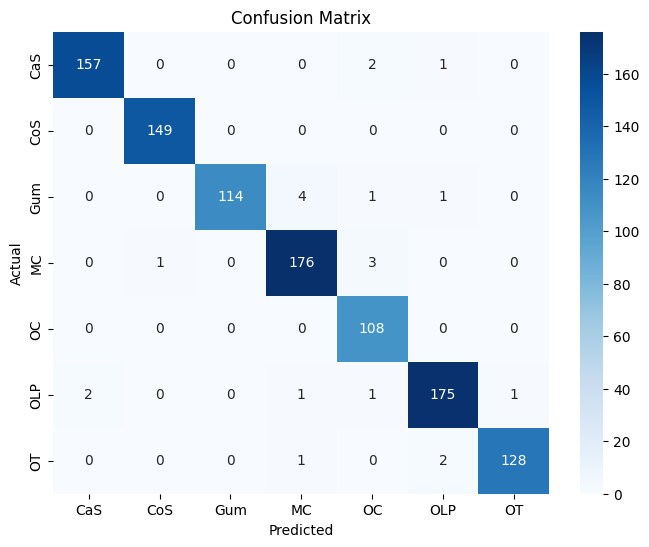

In [26]:
# Classification Report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_probs = model.predict(ds_val)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = []
for images, labels in ds_val:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
y_true = np.array(y_true)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
